In [8]:
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path
from pickle import load

import matplotlib as mpl

mpl.rcParams.update({
    # Use LaTeX
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Lines
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 1,

    # Ticks
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # Save figures
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})


In [10]:
if charge_stability['charge_stability']:
    list(charge_stability['charge_stability'].items())[-1]
else:
    'No completed voltage points yet.'


In [11]:
def empty_grid():
    return np.full((len(voltage_grid_v), len(voltage_grid_v)), np.nan)


def symmetric_grid(values_by_grid_point):
    grid = empty_grid()
    for (i, j), value in values_by_grid_point.items():
        grid[j, i] = value
        if i != j:
            grid[i, j] = value
    return grid


def stable_charge_grid(charge_stability):
    return symmetric_grid({
        key: n
        for key, (n, energy) in charge_stability['charge_stability'].items()
    })


def stable_energy_grid_mev(charge_stability):
    return symmetric_grid({
        key: energy * energy_to_mev
        for key, (n, energy) in charge_stability['charge_stability'].items()
    })


def total_energy_grid_mev(n_electrons):
    values = {}
    for key, run in charge_stability['runs_by_grid_point'].items():
        result = point_result(run, n_electrons)
        if result is not None:
            values[key] = float(result['energy']) * energy_to_mev
    return symmetric_grid(values)


def completed_voltage_extent(grid):
    valid_j, valid_i = np.where(~np.isnan(grid))
    if valid_i.size == 0:
        raise ValueError('No completed points found for this plot.')
    imax = max(valid_i.max(), valid_j.max())
    return voltage_grid_mV[0], voltage_grid_mV[imax]


def plot_grid(grid, *, cmap, colorbar_label, title=None, discrete_bounds=None):
    masked = np.ma.masked_invalid(grid)
    x_min, x_max = completed_voltage_extent(grid)
    y_min, y_max = x_min, x_max

    fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=200)

    norm = None
    if discrete_bounds is not None:
        norm = mpl.colors.BoundaryNorm(discrete_bounds, cmap.N)

    im = ax.imshow(
        masked,
        origin='lower',
        extent=[voltage_grid_mV[0], voltage_grid_mV[-1], voltage_grid_mV[0], voltage_grid_mV[-1]],
        cmap=cmap,
        norm=norm,
        interpolation='nearest',
        aspect='equal',
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    if title is not None:
        ax.set_title(title)
    ax.set_xlabel(r'$V_L$ (mV)')
    ax.set_ylabel(r'$V_R$ (mV)')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    fig.tight_layout()
    return fig, ax


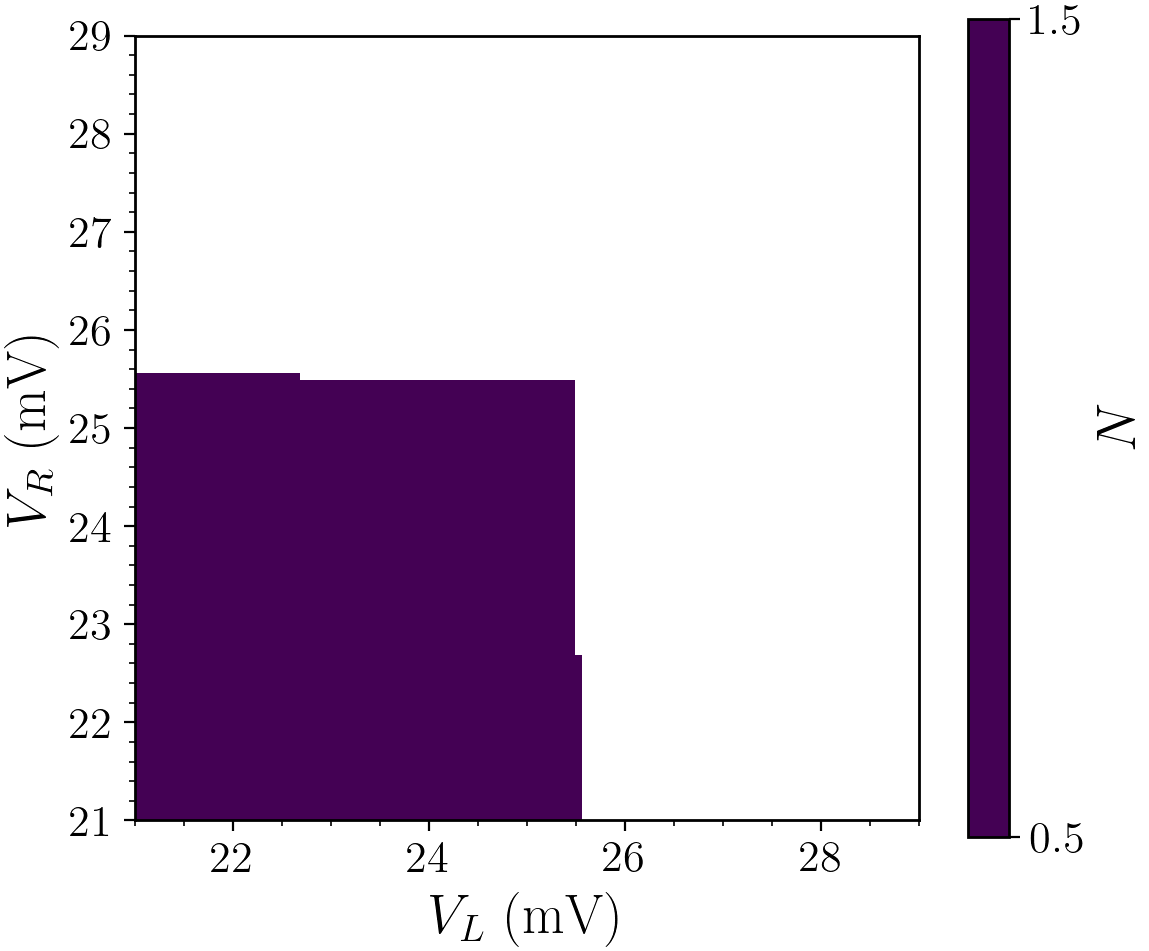

In [12]:
n_grid = stable_charge_grid(charge_stability)

valid_n = n_grid[~np.isnan(n_grid)].astype(int)
if valid_n.size == 0:
    raise ValueError('No charge-stability points found.')

n_min = valid_n.min()
n_max = valid_n.max()

cmap = plt.get_cmap('viridis', n_max - n_min + 1).copy()
cmap.set_bad('white')
bounds = np.arange(n_min - 0.5, n_max + 1.5, 1)

fig, ax = plot_grid(
    n_grid,
    cmap=cmap,
    colorbar_label=r'$N$',
    discrete_bounds=bounds,
)

if n_max > n_min:
    ax.contour(
        voltage_grid_mV,
        voltage_grid_mV,
        n_grid,
        levels=np.arange(n_min + 0.5, n_max + 0.5, 1),
        colors='k',
        linewidths=0.8,
    )

ax.set_xlim(voltage_grid_mV[0], voltage_grid_mV[-1])
ax.set_ylim(voltage_grid_mV[0], voltage_grid_mV[-1])
#fig.axes[-1].set_ticks(np.arange(n_min, n_max + 1))
plt.show()


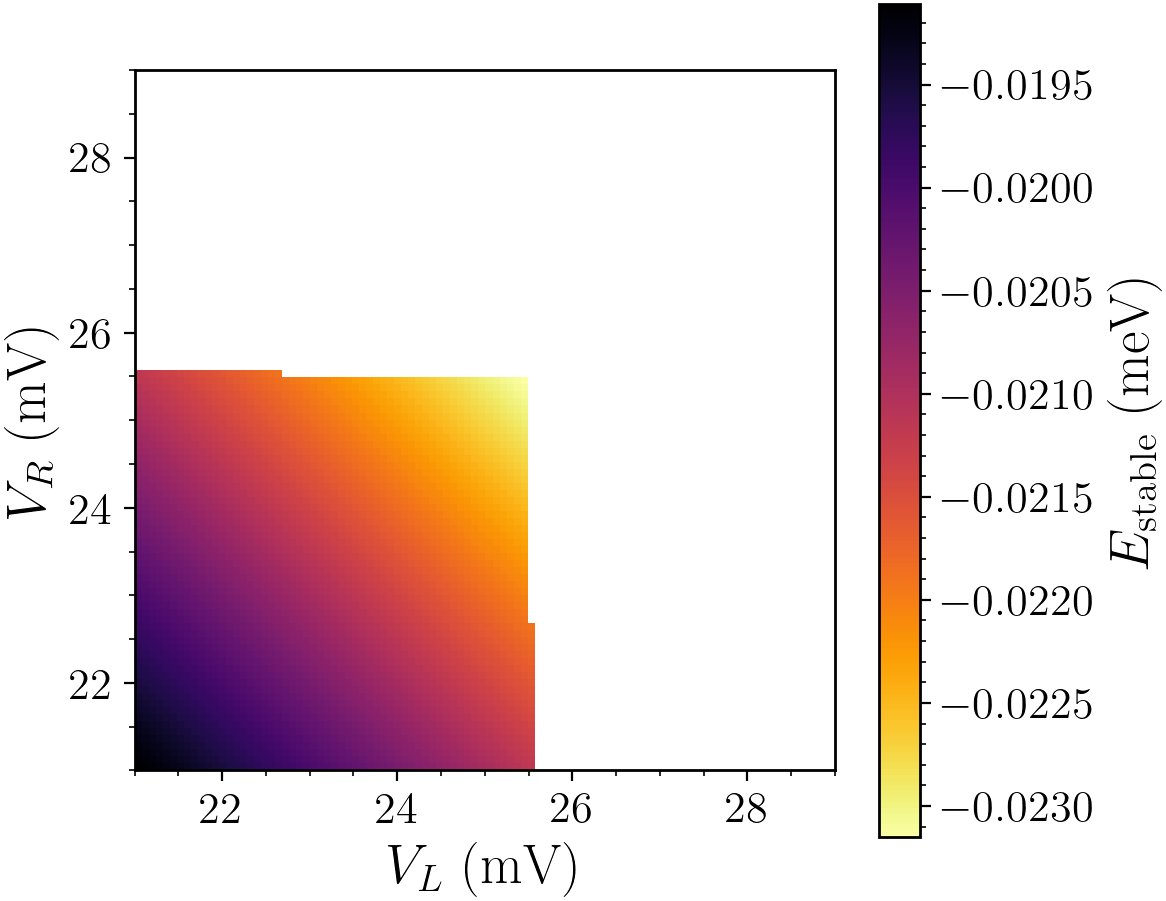

In [13]:
energy_grid = stable_energy_grid_mev(charge_stability)

cmap = plt.get_cmap('inferno_r').copy()
cmap.set_bad('white')

fig, ax = plot_grid(
    energy_grid,
    cmap=cmap,
    colorbar_label=r'$E_\mathrm{stable}$ (meV)',
)

ax.set_xlim(voltage_grid_mV[0], voltage_grid_mV[-1])
ax.set_ylim(voltage_grid_mV[0], voltage_grid_mV[-1])

plt.show()


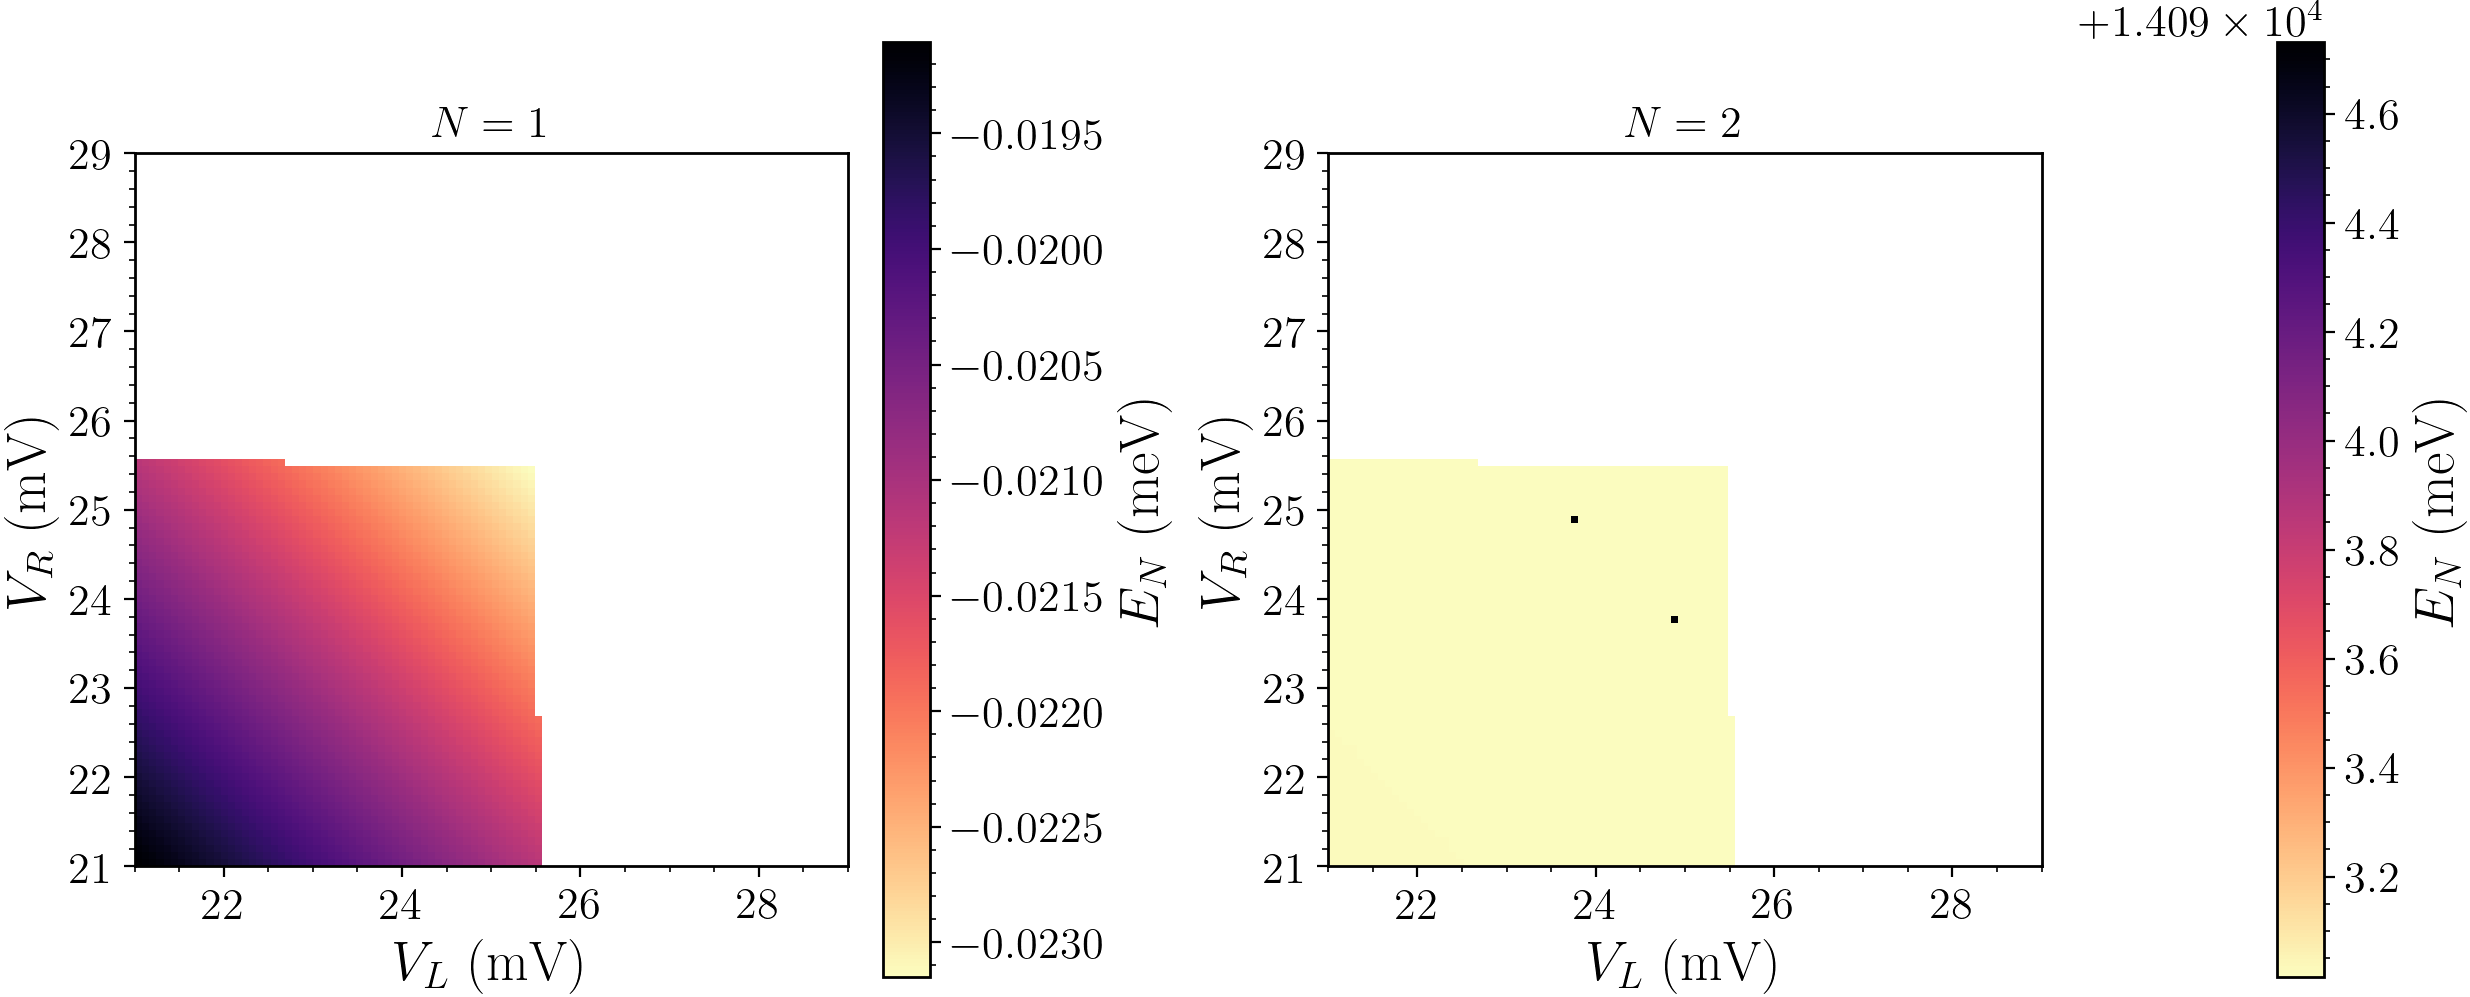

In [14]:
electron_counts = [1, 2]
fig, axes = plt.subplots(1, len(electron_counts), figsize=(12.4, 5.2), dpi=200, constrained_layout=True)

if len(electron_counts) == 1:
    axes = [axes]

for ax, n_electrons in zip(axes, electron_counts):
    grid = total_energy_grid_mev(n_electrons)
    if np.isnan(grid).all():
        ax.set_visible(False)
        print(f'No completed N={n_electrons} energies found.')
        continue

    x_min, x_max = completed_voltage_extent(grid)
    cmap = plt.get_cmap('magma_r').copy()
    cmap.set_bad('white')

    im = ax.imshow(
        np.ma.masked_invalid(grid),
        origin='lower',
        extent=[voltage_grid_mV[0], voltage_grid_mV[-1], voltage_grid_mV[0], voltage_grid_mV[-1]],
        cmap=cmap,
        interpolation='nearest',
        aspect='equal',
    )
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r'$E_N$ (meV)')

    ax.set_title(rf'$N={n_electrons}$')
    ax.set_xlabel(r'$V_L$ (mV)')
    ax.set_ylabel(r'$V_R$ (mV)')
    ax.set_xlim(voltage_grid_mV[0], voltage_grid_mV[-1])
    ax.set_ylim(voltage_grid_mV[0], voltage_grid_mV[-1])

plt.show()
